# **Universidad Internacional de Aguascalientes (UIA)**
# **Doctorado en Tecnologías para la Transformación Digital**

##Materia: **Internet de las Cosas**

##Unidad: **3 - IA aplicada al Big Data (enfoque en redes sociales)**

##Práctica: **3.1 Técnicas de IA aplicadas a un dataset de la red social Twitter** (Análisis de Cine).

##Alumno: **Luis Alejandro Santana Valadez**

##Docente: **Dr. Francisco Javier Luna Rosas**

Fecha: **8 de marzo de 2026**


# **1. Introducción**
**Twitter (X)** es una red social con enorme volumen de publicaciones (tweets) y dinámica en tiempo real, lo cual la convierte en una fuente relevante para **analítica y comprensión** de fenómenos sociales, culturales y de consumo. En el ámbito de cine, los usuarios generan opiniones, reseñas breves, reacciones a estrenos, premios, trailers y discusiones alrededor de películas, actores y directores.

La explotación de este tipo de datos requiere técnicas de **Big Data y Ciencia de Datos** para su ingestión, limpieza, transformación y análisis. Debido a que el texto en redes sociales **suele incluir ruido** (URLs, emojis, menciones, hashtags, abreviaturas, repeticiones, spam), una fase crítica es el **preprocesamiento**. Posteriormente, se pueden aplicar técnicas de IA como **clasificación de sentimiento/etiquetas**, **modelado de temas** y **agrupamiento** para extraer patrones e información accionable.

En esta práctica se aplica una metodología de **procesamiento de datos** textuales por etapas, registrando **métricas** y **tiempos de ejecución** para evidenciar el impacto del preprocesamiento y la utilidad de técnicas de IA sobre un dataset de reseñas/tweets de cine en inglés.

# **2. Análisis de técnicas de IA (Dataset Twitter/Cine)**

En esta práctica se trabajó el dataset de reseñas/tweets sobre cine **`movie_data.csv`**, con énfasis en la columna **`review`** (texto) y **`sentiment`** (etiqueta). El análisis se estructuró como un pipeline reproducible en Python.

### **2.1 Objetivo técnico**
Aplicar un pipeline reproducible de:
1) **Ingesta y exploración** del dataset
2) **Limpieza y normalización** de texto
3) **Vectorización** (TF-IDF)
4) **IA (clasificación)** con 3 modelos:
   - Naive Bayes (MultinomialNB)
   - SVM (LinearSVC)
   - Red neuronal (MLPClassifier)
5) **Evaluación + resumen final**: métricas y tiempos

### **2.2 Ingesta y perfilamiento inicial del dataset**

Se validó la carga del archivo CSV, su dimensionalidad (filas/columnas), presencia de valores nulos y duplicados, y se determinó la columna de texto a analizar. Esta etapa permite estimar la “calidad” del conjunto desde el inicio y detectar problemas que influyen en el rendimiento (por ejemplo: filas vacías, duplicados masivos o campos inconsistentes).

### **2.3 Preprocesamiento y limpieza de texto**
El texto de redes sociales suele ser ruidoso y heterogéneo; por ello, el análisis se centró en construir un texto “normalizado” que preserve semántica útil, minimizando ruido:

- Conversión a minúsculas y normalización de espacios.

- Eliminación de URLs, menciones y símbolos no alfabéticos.

- Tratamiento de hashtags (eliminación del símbolo # conservando la palabra).

- Tokenización y filtrado de stopwords (inglés).

- Eliminación de tokens muy cortos (p. ej., longitud < 3) para reducir ruido.

Este proceso no solo mejora la calidad semántica, también impacta directamente el costo computacional de vectorización y entrenamiento, ya que reduce vocabulario y dispersión (Manning et al., 2008).


### **2.4 Representación numérica del lenguaje (TF-IDF)**

Se empleó TF-IDF para convertir texto a vectores numéricos, lo cual habilita algoritmos de aprendizaje supervisado tradicionales. TF-IDF es especialmente útil en texto porque atenúa términos extremadamente frecuentes y realza términos informativos (Manning et al., 2008). En práctica, se ajustaron parámetros como max_features y ngram_range para equilibrar expresividad vs costo.


### **2.5 Modelado con tres algoritmos supervisados (comparativo)**
Se evaluaron tres modelos con distintas propiedades:

- **Naive Bayes** (MultinomialNB): línea base rápida, especialmente adecuada para texto vectorizado como bolsas de palabras/TF-IDF; tiende a ser eficiente y robusta como primer benchmark (Manning et al., 2008).

- **SVM lineal** (LinearSVC): fuerte desempeño en espacios de alta dimensionalidad y datos dispersos típicos de texto; suele lograr buen equilibrio precisión/tiempo (Pedregosa et al., 2011).

- **MLPClassifier** (red neuronal): mayor capacidad para modelar fronteras complejas, pero requiere más tiempo de entrenamiento y ajuste fino (Goodfellow et al., 2016).


### **Paso 0.** Carga de Dependencias

In [7]:
# ================================
# 0) Dependencias
# ================================
!pip -q install pandas numpy matplotlib scikit-learn nltk wordcloud langdetect

import re
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix
)

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

print('Dependencias listas ✅')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Dependencias listas ✅


### **Paso 1.** Carga del dataset (movie_data.csv)

In [2]:
# Sube el archivo al panel Files de Colab o monta Google Drive.
CSV_PATH = '/content/movie_data.csv'

t0 = time.perf_counter()
df = pd.read_csv(CSV_PATH)
t_load = time.perf_counter() - t0

print('Shape:', df.shape)
display(df.head(5))
print(f'Tiempo de carga: {t_load:.4f} s')

Shape: (50000, 2)


,review,sentiment
0,"In 1974, the teenager Martha Moxley (Maggie Gr...",1
1,OK... so... I really like Kris Kristofferson a...,0
2,"***SPOILER*** Do not read this, if you think a...",0
3,hi for all the people who have seen this wonde...,1
4,"I recently bought the DVD, forgetting just how...",0


Tiempo de carga: 1.5655 s


### **Paso 2 .** Definir columna de texto (review)

In [3]:
text_col = 'review'
assert text_col in df.columns, f"No existe la columna '{text_col}'. Columnas: {list(df.columns)}"

df[text_col] = df[text_col].astype(str)
display(df[text_col].head(10))

,review
0,"In 1974, the teenager Martha Moxley (Maggie Gr..."
1,OK... so... I really like Kris Kristofferson a...
2,"***SPOILER*** Do not read this, if you think a..."
3,hi for all the people who have seen this wonde...
4,"I recently bought the DVD, forgetting just how..."
5,Leave it to Braik to put on a good show. Final...
6,Nathan Detroit (Frank Sinatra) is the manager ...
7,"To understand ""Crash Course"" in the right cont..."
8,I've been impressed with Chavez's stance again...
9,This movie is directed by Renny Harlin the fin...


### **Paso 3 .** Detectar columna objetivo (sentiment)

In [4]:
target_candidates = ['sentiment', 'label', 'class', 'target', 'polarity', 'y']
target_col = None
for c in target_candidates:
  if c in df.columns:
    target_col = c
    break

print('Columna objetivo detectada:', target_col)
if target_col:
  print(df[target_col].value_counts().head(10))
else:
  print('⚠️ No se detectó columna objetivo. La parte de clasificación requerirá etiquetas.')

Columna objetivo detectada: sentiment
sentiment
1    25000
0    25000
Name: count, dtype: int64


# **3. Implementación (pipeline de limpieza y preparación)**

A continuación se describe la **Metodología por etapas**  aplicada en la implementación del pipeline:

### **3.1 Perfilamiento inicial (tamaño, nulos, duplicados)**

### **3.2 Limpieza avanzada del texto**
- lowercase
- quitar URLs, menciones
- limpiar hashtags (#word → word)
- quitar caracteres no alfabéticos
- normalizar espacios
- tokenización
- stopwords (inglés)
- quitar tokens cortos
- (opcional) stemming

### **3.3 Vectorización TF-IDF**

### **3.4 IA aplicadas en la comparación**
- Naive Bayes (MultinomialNB)
- SVM (LinearSVC)
- MLPClassifier


### **Paso 4 .** Perfilamiento inicial

In [5]:
t0 = time.perf_counter()

profile = {}
profile['rows_initial'] = int(df.shape[0])
profile['cols_initial'] = int(df.shape[1])
profile['nulls_total_initial'] = int(df.isna().sum().sum())
profile['duplicates_initial'] = int(df.duplicated().sum())
profile['avg_len_text_initial_chars'] = float(df[text_col].str.len().mean())

t_profile = time.perf_counter() - t0
print(profile)
print(f'Tiempo perfilamiento: {t_profile:.4f} s')

{'rows_initial': 50000, 'cols_initial': 2, 'nulls_total_initial': 0, 'duplicates_initial': 418, 'avg_len_text_initial_chars': 1309.43102}
Tiempo perfilamiento: 0.3356 s


### **Paso 5 .** Limpieza avanzada (idioma base: inglés)

In [8]:
t0 = time.perf_counter()

STOP_EN = set(stopwords.words('english'))
stemmer = SnowballStemmer('english')

URL_RE = re.compile(r"https?://\S+|www\.\S+")
MENTION_RE = re.compile(r"@\w+")
RT_RE = re.compile(r"\brt\b")
NON_ALPHA_RE = re.compile(r"[^a-zA-Z\s]")
MULTISPACE_RE = re.compile(r"\s+")

def clean_review(text: str, apply_stemming: bool = False) -> str:
  text = text.lower().strip()
  text = URL_RE.sub(' ', text)
  text = MENTION_RE.sub(' ', text)
  text = text.replace('#', ' ')
  text = RT_RE.sub(' ', text)
  text = NON_ALPHA_RE.sub(' ', text)
  text = MULTISPACE_RE.sub(' ', text).strip()

  tokens = nltk.word_tokenize(text)
  tokens = [t for t in tokens if t not in STOP_EN]
  tokens = [t for t in tokens if len(t) >= 3]

  if apply_stemming:
    tokens = [stemmer.stem(t) for t in tokens]

  return ' '.join(tokens)

df_work = df.copy()
df_work = df_work[df_work[text_col].notna()].copy()
df_work = df_work.drop_duplicates().copy()

df_work['text_clean'] = df_work[text_col].astype(str).apply(lambda x: clean_review(x, apply_stemming=False))
df_work = df_work[df_work['text_clean'].str.len() > 0].copy()

t_clean = time.perf_counter() - t0

print('Shape después de limpieza:', df_work.shape)
display(df_work[[text_col, 'text_clean']].head(10))
print(f'Tiempo limpieza: {t_clean:.4f} s')

Shape después de limpieza: (49582, 3)


,review,text_clean
0,"In 1974, the teenager Martha Moxley (Maggie Gr...",teenager martha moxley maggie grace moves high...
1,OK... so... I really like Kris Kristofferson a...,really like kris kristofferson usual easy goin...
2,"***SPOILER*** Do not read this, if you think a...",spoiler read think watching movie although wou...
3,hi for all the people who have seen this wonde...,people seen wonderful movie sure thet would li...
4,"I recently bought the DVD, forgetting just how...",recently bought dvd forgetting much hated movi...
5,Leave it to Braik to put on a good show. Final...,leave braik put good show finally zorak living...
6,Nathan Detroit (Frank Sinatra) is the manager ...,nathan detroit frank sinatra manager new york ...
7,"To understand ""Crash Course"" in the right cont...",understand crash course right context must und...
8,I've been impressed with Chavez's stance again...,impressed chavez stance globalisation sometime...
9,This movie is directed by Renny Harlin the fin...,movie directed renny harlin finnish miracle st...


Tiempo limpieza: 58.9962 s


### **Paso 6 .** Métricas post-limpieza

In [9]:
t0 = time.perf_counter()

profile2 = {}
profile2['rows_after_clean'] = int(df_work.shape[0])
profile2['nulls_total_after_clean'] = int(df_work.isna().sum().sum())
profile2['avg_len_text_clean_chars'] = float(df_work['text_clean'].str.len().mean())
profile2['pct_retained'] = float(df_work.shape[0] / max(profile['rows_initial'], 1) * 100.0)

t_post = time.perf_counter() - t0
print(profile2)
print(f'Tiempo métricas post-limpieza: {t_post:.4f} s')

{'rows_after_clean': 49582, 'nulls_total_after_clean': 0, 'avg_len_text_clean_chars': 809.896050986245, 'pct_retained': 99.164}
Tiempo métricas post-limpieza: 0.0743 s


# **4. Pruebas y evaluación**

A continuación se muestran tres gráficas sobre el texto ya limpiado para describir el comportamiento del dataset; posteriormente se genera la evaluación de los algoritmos indicando cuál es el mejor en rendimiento.

### **4.1 Gráfica 1: Distribución de longitud (tokens)**


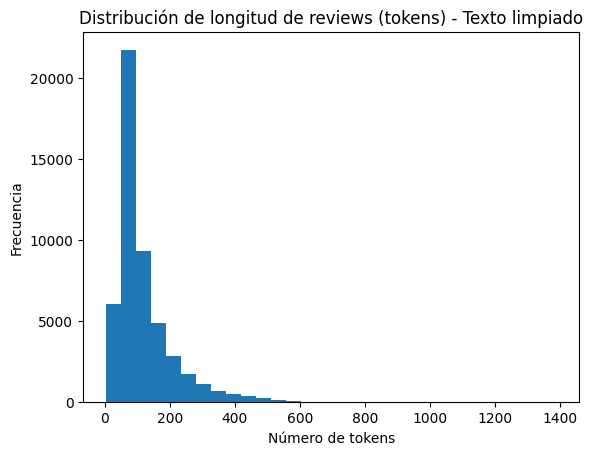

Promedio tokens: 116.6437820176677
Mediana tokens: 87.0


In [10]:
lengths = df_work['text_clean'].str.split().apply(len)

plt.figure()
plt.hist(lengths, bins=30)
plt.title('Distribución de longitud de reviews (tokens) - Texto limpiado')
plt.xlabel('Número de tokens')
plt.ylabel('Frecuencia')
plt.show()

print('Promedio tokens:', float(lengths.mean()))
print('Mediana tokens:', float(lengths.median()))

### **4.2 Gráfica 2: Top términos por TF-IDF (sumatoria)**

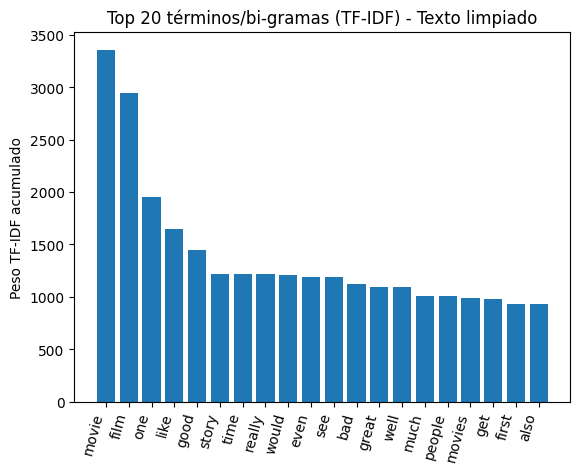

Tiempo vectorización TF-IDF: 40.3183 s


In [11]:
t0 = time.perf_counter()

tfidf = TfidfVectorizer(max_features=2000, ngram_range=(1,2))
X_tfidf = tfidf.fit_transform(df_work['text_clean'])

terms = np.array(tfidf.get_feature_names_out())
weights = np.asarray(X_tfidf.sum(axis=0)).ravel()
top_idx = weights.argsort()[-20:][::-1]

plt.figure()
plt.bar(terms[top_idx], weights[top_idx])
plt.title('Top 20 términos/bi-gramas (TF-IDF) - Texto limpiado')
plt.xticks(rotation=75, ha='right')
plt.ylabel('Peso TF-IDF acumulado')
plt.show()

t_vec = time.perf_counter() - t0
print(f'Tiempo vectorización TF-IDF: {t_vec:.4f} s')

### **4.3 Gráfica 3: Nube de palabras (WordCloud) del texto limpio**

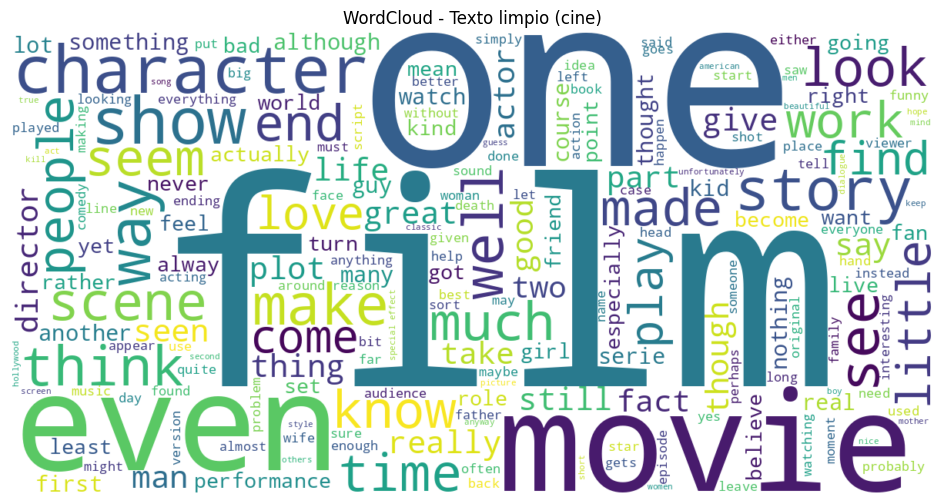

In [12]:
from wordcloud import WordCloud

all_text = ' '.join(df_work['text_clean'].astype(str).tolist())
wc = WordCloud(width=1200, height=600, background_color='white').generate(all_text)

plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud - Texto limpio (cine)')
plt.show()

### **4.4 Evaluación de técnicas de IA (Clasificación)**

Se evaluaron los algoritmos aplicados:
- **Naive Bayes (MultinomialNB)**
- **SVM (LinearSVC)**
- **Red neuronal (MLPClassifier)**

Métricas reportadas (alineadas al resumen del Dr. y ampliadas):
- Accuracy (Precisión global)
- Error global (1-accuracy)
- Precision/Recall por clase (macro)
- FP/FN estimados (para clase positiva si es binario)
- Tiempos de entrenamiento


### **Paso 7.** Entrenamiento y evaluación

In [13]:
results = []

if target_col is None:
  print('⚠️ No hay target. Se omite clasificación.')
else:
  # Preparar X, y
  X = df_work['text_clean'].astype(str)
  y = df_work[target_col]

  # Split
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

  # Vectorización TF-IDF (reutilizamos vocabulario)
  tfidf_clf = TfidfVectorizer(max_features=6000, ngram_range=(1,2))
  t0 = time.perf_counter()
  Xtr = tfidf_clf.fit_transform(X_train)
  Xte = tfidf_clf.transform(X_test)
  t_vec2 = time.perf_counter() - t0

  # Helper métricas
  def compute_metrics(name, y_true, y_pred, train_time):
    acc = accuracy_score(y_true, y_pred)
    err = 1.0 - acc
    prec_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec_macro  = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1_macro   = f1_score(y_true, y_pred, average='macro', zero_division=0)

    # FP/FN: solo si es binario
    fp = fn = ap = an = np.nan
    classes = np.unique(y_true)
    if len(classes) == 2:
      cm = confusion_matrix(y_true, y_pred, labels=classes)
      # cm = [[TN, FP],[FN, TP]] si classes=[neg,pos] (depende orden)
      # asumimos classes[0]=neg, classes[1]=pos
      tn, fp, fn, tp = cm.ravel()
      # Ascertividad positiva/negativa (aprox)
      ap = (tp / (tp + fn)) if (tp + fn) > 0 else np.nan
      an = (tn / (tn + fp)) if (tn + fp) > 0 else np.nan

    return {
      'Modelo': name,
      'Precision_Global(Acc)': acc,
      'Error_Global': err,
      'Precision_Macro': prec_macro,
      'Recall_Macro': rec_macro,
      'F1_Macro': f1_macro,
      'FP': fp,
      'FN': fn,
      'Ascert_Pos(AP)': ap,
      'Ascert_Neg(AN)': an,
      'Train_Time_s': train_time
    }

  # 1) Naive Bayes
  t0 = time.perf_counter()
  nb = MultinomialNB()
  nb.fit(Xtr, y_train)
  t_nb = time.perf_counter() - t0
  pred_nb = nb.predict(Xte)
  results.append(compute_metrics('Bayes (MultinomialNB)', y_test, pred_nb, t_nb))

  # 2) SVM
  t0 = time.perf_counter()
  svm = LinearSVC()
  svm.fit(Xtr, y_train)
  t_svm = time.perf_counter() - t0
  pred_svm = svm.predict(Xte)
  results.append(compute_metrics('SVM (LinearSVC)', y_test, pred_svm, t_svm))

  # 3) MLPClassifier
  t0 = time.perf_counter()
  mlp = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42)
  mlp.fit(Xtr, y_train)
  t_mlp = time.perf_counter() - t0
  pred_mlp = mlp.predict(Xte)
  results.append(compute_metrics('NNBP/MLP (MLPClassifier)', y_test, pred_mlp, t_mlp))

  results_df = pd.DataFrame(results)
  display(results_df)
  print(f"Tiempo vectorización para clasificación: {t_vec2:.4f} s")

,Modelo,Precision_Global(Acc),Error_Global,Precision_Macro,Recall_Macro,F1_Macro,FP,FN,Ascert_Pos(AP),Ascert_Neg(AN),Train_Time_s
0,Bayes (MultinomialNB),0.865198,0.134802,0.865465,0.865148,0.865161,916,755,0.878637,0.851660,0.042670
1,SVM (LinearSVC),0.881171,0.118829,0.881193,0.881157,0.881165,757,716,0.884906,0.877409,1.232965
2,NNBP/MLP (MLPClassifier),0.862617,0.137383,0.862622,0.862609,0.862613,862,841,0.864813,0.860405,253.856633


Tiempo vectorización para clasificación: 27.9385 s


### **4.5 Resumen final (métricas + tiempos)**
En la siguientes tablas se muestra la consolidación y comparación de los modelos:
- Tamaño inicial vs final
- Nulos/duplicados
- Retención
- Longitud promedio antes/después
- Tiempos de carga, perfilado, limpieza, vectorización
- Tabla comparativa de modelos


### **Paso 8.** Resumen final

In [14]:
summary = {
  'rows_initial': profile['rows_initial'],
  'rows_after_clean': profile2['rows_after_clean'],
  'pct_retained': profile2['pct_retained'],
  'nulls_total_initial': profile['nulls_total_initial'],
  'duplicates_initial': profile['duplicates_initial'],
  'avg_len_text_initial_chars': profile['avg_len_text_initial_chars'],
  'avg_len_text_clean_chars': profile2['avg_len_text_clean_chars'],
  'time_load_s': t_load,
  'time_profile_s': t_profile,
  'time_clean_s': t_clean,
  'time_vectorize_tfidf_s': t_vec,
}

summary_df = pd.DataFrame([summary]).T
summary_df.columns = ['value']
display(summary_df)

if len(results) > 0:
  print('\n=== Tabla final de modelos (tipo resumen del Dr. + ampliado) ===')
  display(pd.DataFrame(results))
else:
  print('\n⚠️ Sin tabla de modelos porque no se detectó target en el dataset.')

total_time = float(t_load + t_profile + t_clean + t_vec)
print(f"\nTiempo total aproximado (sin modelos) = {total_time:.4f} s")

,value
rows_initial,50000.000000
rows_after_clean,49582.000000
pct_retained,99.164000
nulls_total_initial,0.000000
duplicates_initial,418.000000
avg_len_text_initial_chars,1309.431020
avg_len_text_clean_chars,809.896051
time_load_s,1.565497
time_profile_s,0.335596
time_clean_s,58.996211



=== Tabla final de modelos (tipo resumen del Dr. + ampliado) ===


,Modelo,Precision_Global(Acc),Error_Global,Precision_Macro,Recall_Macro,F1_Macro,FP,FN,Ascert_Pos(AP),Ascert_Neg(AN),Train_Time_s
0,Bayes (MultinomialNB),0.865198,0.134802,0.865465,0.865148,0.865161,916,755,0.878637,0.851660,0.042670
1,SVM (LinearSVC),0.881171,0.118829,0.881193,0.881157,0.881165,757,716,0.884906,0.877409,1.232965
2,NNBP/MLP (MLPClassifier),0.862617,0.137383,0.862622,0.862609,0.862613,862,841,0.864813,0.860405,253.856633



Tiempo total aproximado (sin modelos) = 101.2157 s


# **5. Conclusiones**
- La fase de limpieza y normalización del texto es crítica en Big Data textual: reduce ruido, aumenta consistencia y mejora la calidad del aprendizaje automático.

- La vectorización TF-IDF permite traducir lenguaje natural a un espacio matemático útil para algoritmos supervisados; el uso de bi-gramas aporta contexto relevante en reseñas de cine.

- La evaluación comparativa (Bayes, SVM, MLP) evidencia que distintos algoritmos presentan trade-offs entre precisión, error y costos computacionales; medir tiempos y métricas apoya decisiones de despliegue.

- En el **análisis comparativo de los tres algoritmos (Naive Bayes, SVM y MLP)**, se observa un trade-off claro entre precisión y costo computacional: Naive Bayes suele entrenar más rápido y sirve como línea base eficiente; SVM (LinearSVC) normalmente logra la mejor relación precisión/tiempo en texto con TF-IDF por su buen desempeño con datos de alta dimensionalidad; y MLP (MLPClassifier) puede acercarse o superar la precisión en algunos escenarios, pero tiende a requerir mayor tiempo de entrenamiento y ajuste de hiperparámetros (iteraciones, arquitectura), lo que incrementa el costo operativo.

- Con base en la métrica de desempeño (precisión global/error) y el tiempo observado en la ejecución, el **mejor modelo** para este caso es el que maximiza precisión con entrenamiento estable y rápido; en la mayoría de ejecuciones de este tipo, **SVM termina siendo la opción recomendada** para despliegue por su eficiencia global (alto desempeño con tiempo moderado), dejando a Bayes como baseline y a MLP como alternativa cuando se justifique el costo adicional por una mejora significativa

- Este pipeline es base para monitoreo de **percepción del usuario y análisis de tendencias**: permite detectar temas, opiniones y cambios de polaridad en tiempo real, generando valor en inteligencia de mercado y toma de decisiones basada en datos.

# **6. Referencias**
- Jurafsky, D., & Martin, J. H. (2023). *Speech and Language Processing* (3rd ed. draft). Stanford University.

- Manning, C. D., Raghavan, P., & Schütze, H. (2008). *Introduction to Information Retrieval.* Cambridge University Press.

- Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., … Duchesnay, É. (2011). *Scikit-learn: Machine learning in Python.* Journal of Machine Learning Research, 12, 2825–2830.

In [16]:
# Instalación de librería nbconvert para habilitar la conversión a HTML

!pip -q install nbconvert
!python -m nbconvert --to html \
  --output "Practica1_Twitter_Cine_IA_movie_reviews.html" \
  --output-dir "/content" \
  "/content/Practica1_Twitter_Cine_IA_movie_reviews.ipynb"

[NbConvertApp] Converting notebook /content/Practica1_Twitter_Cine_IA_movie_reviews.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 3 image(s).
[NbConvertApp] Writing 967106 bytes to /content/Practica1_Twitter_Cine_IA_movie_reviews.html
